--- Dataset Audit ---
Total Patient Records: 303
Missing Values: 0
Model Diagnostic Accuracy: 54.10%

Detailed Clinical Report:
              precision    recall  f1-score   support

           0       0.55      0.55      0.55        31
           1       0.53      0.53      0.53        30

    accuracy                           0.54        61
   macro avg       0.54      0.54      0.54        61
weighted avg       0.54      0.54      0.54        61



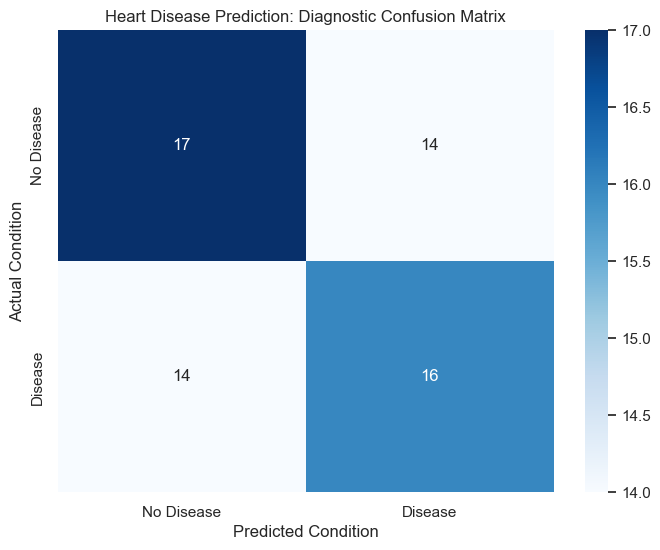

In [2]:

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score

sns.set_theme(style="whitegrid", palette="RdBu")
%matplotlib inline

try:
    df = pd.read_csv('heart_disease_data.csv')
    print("--- Dataset Audit ---")
    print(f"Total Patient Records: {df.shape[0]}")
    print(f"Missing Values: {df.isnull().sum().sum()}")
except FileNotFoundError:
    print("Please ensure 'heart_disease_data.csv' is in your directory.")

df.head()

X = df.drop('target', axis=1)
y = df['target']

# Scaling numerical features
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# Stratified split to maintain clinical case ratios
X_train, X_test, y_train, y_test = train_test_split(
    X_scaled, y, test_size=0.2, random_state=42, stratify=y
)

model = RandomForestClassifier(n_estimators=100, max_depth=7, random_state=42)
model.fit(X_train, y_train)


y_pred = model.predict(X_test)

print(f"Model Diagnostic Accuracy: {accuracy_score(y_test, y_pred):.2%}")
print("\nDetailed Clinical Report:")
print(classification_report(y_test, y_pred))



plt.figure(figsize=(8, 6))
cm = confusion_matrix(y_test, y_pred)
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', 
            xticklabels=['No Disease', 'Disease'], 
            yticklabels=['No Disease', 'Disease'])

plt.title("Heart Disease Prediction: Diagnostic Confusion Matrix")
plt.xlabel("Predicted Condition")
plt.ylabel("Actual Condition")
plt.show()

